<a href="https://colab.research.google.com/github/Vars118/Exoplanet-Detection-AI/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vars006","key":"8a5ccc328dfc568edfb23142f7d208d3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s exoplanet

ref                                                            title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nasa/kepler-exoplanet-search-results                           Kepler Exoplanet Search Results                   1215549  2017-10-10 18:26:59.497000          23251        863  0.8235294        
mrisdal/open-exoplanet-catalogue                               Open Exoplanet Catalogue                           126120  2017-06-08 19:59:22.310000           5449        182  0.8235294        
keplersmachines/kepler-labelled-time-series-data               Exoplanet Hunting in Deep Space                  58642135  2017-04-12 16:34:18.383000          18879        599  0.8235294        
kanchana1990/nasa-exoplanet-ar

In [ ]:
!kaggle datasets download -d keplersmachines/kepler-labelled-time-series-data

Dataset URL: https://www.kaggle.com/datasets/keplersmachines/kepler-labelled-time-series-data
License(s): CC0-1.0
100% 55.9M/55.9M [00:00<00:00, 157MB/s]



In [ ]:
!unzip kepler-labelled-time-series-data.zip

Archive:  kepler-labelled-time-series-data.zip
  inflating: exoTest.csv             
  inflating: exoTrain.csv            


Check files

In [ ]:
!ls

exoTest.csv   kaggle.json			    sample_data
exoTrain.csv  kepler-labelled-time-series-data.zip


In [ ]:
import pandas as pd

train = pd.read_csv("exoTrain.csv")
test = pd.read_csv("exoTest.csv")

print(train.shape)
print(test.shape)

(5087, 3198)
(570, 3198)


In [ ]:
train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


Now Check Balance

In [ ]:
train['LABEL'].value_counts()

,count
LABEL,
1,5050
2,37


In [ ]:
train['LABEL'].value_counts(normalize=True)*100

,proportion
LABEL,
1,99.272656
2,0.727344


Now check missing values

In [ ]:
train.isnull().sum().sum()

np.int64(0)

On planet sample

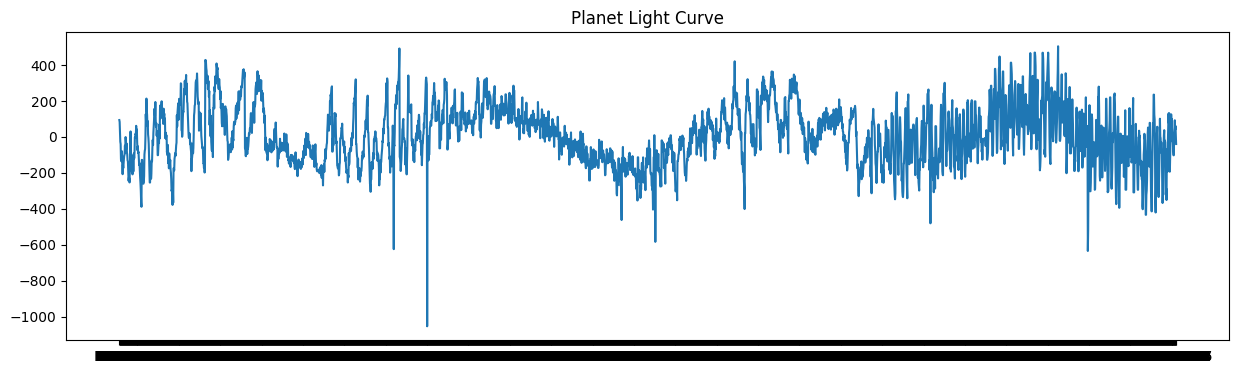

In [ ]:
planet = train[train['LABEL']==2].iloc[0,1:]

plt.figure(figsize=(15,4))
plt.plot(planet)
plt.title("Planet Light Curve")
plt.show()

Non planet sample

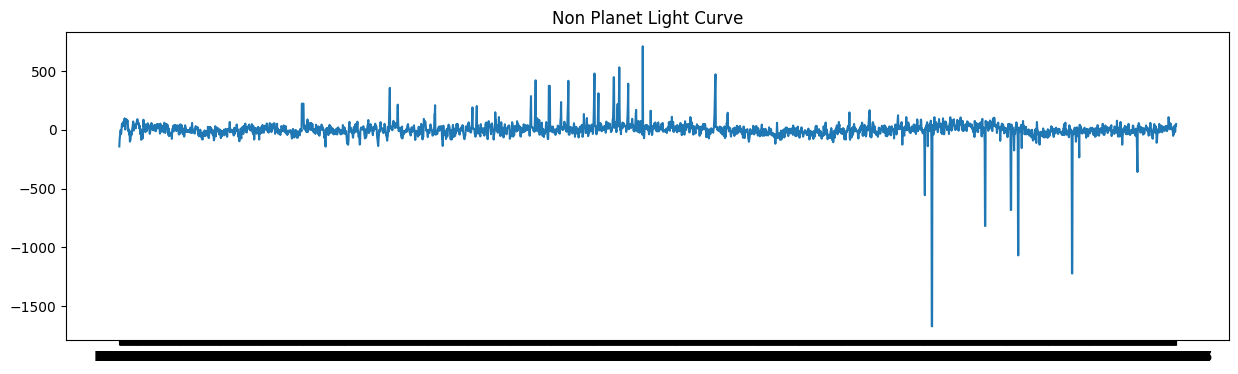

In [ ]:
nonplanet = train[train['LABEL']==1].iloc[0,1:]

plt.figure(figsize=(15,4))
plt.plot(nonplanet)
plt.title("Non Planet Light Curve")
plt.show()

In [ ]:
train.shape

(5087, 3198)

In [ ]:
test.shape

(570, 3198)

In [ ]:

train['LABEL'].value_counts()

,count
LABEL,
1,5050
2,37


Seperate feutures and labels

In [ ]:
X_train = train.drop('LABEL', axis=1)
y_train = train['LABEL']

X_test = test.drop('LABEL', axis=1)
y_test = test['LABEL']

In [ ]:
y_train = y_train.replace({1:0, 2:1})
y_test = y_test.replace({1:0, 2:1})

In [ ]:
y_train.value_counts()

,count
LABEL,
0,5050
1,37


Standardization
Because light curves have diff scales

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Visualise before denoise

In [ ]:
planet = X_train.iloc[0]

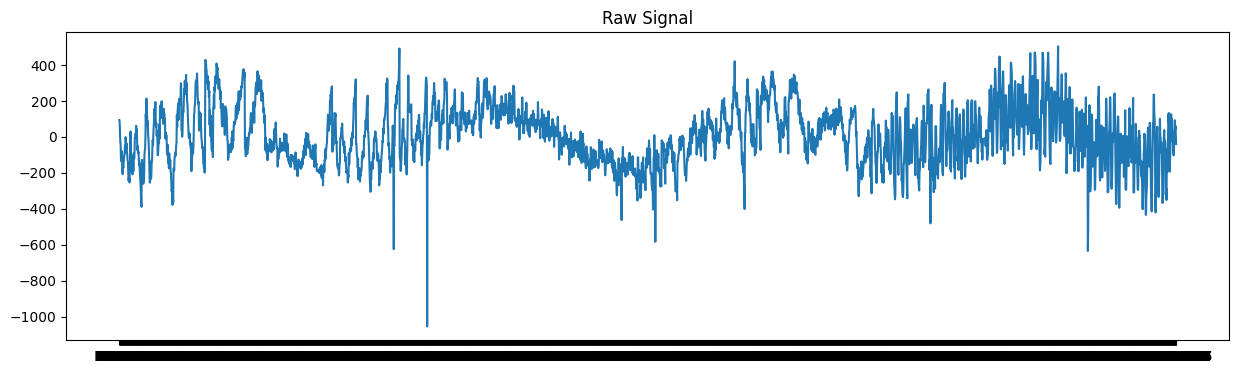

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(planet)
plt.title("Raw Signal")
plt.show()

Installing scipy

In [ ]:
!pip install scipy

First Denoise method

SAVITZKY-GOLAY

In [ ]:
from scipy.signal import savgol_filter

filtered = savgol_filter(
    planet,
    window_length=21,
    polyorder=3
)

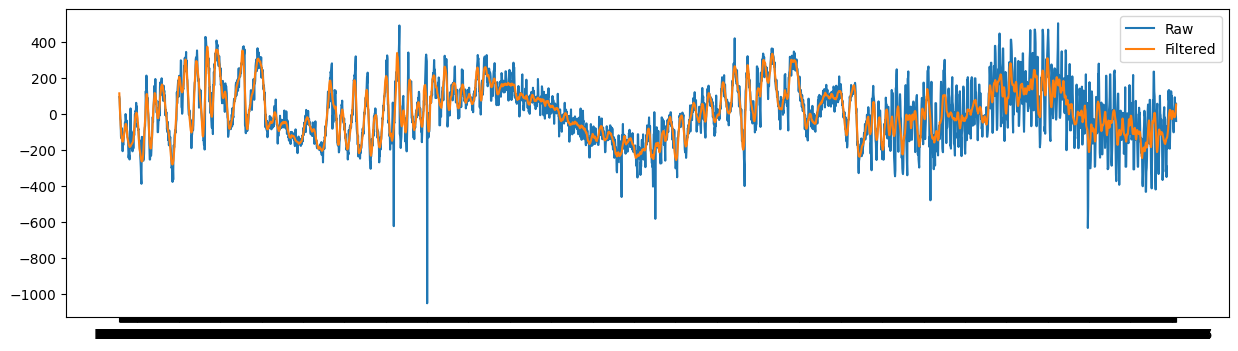

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(planet,label='Raw')
plt.plot(filtered,label='Filtered')
plt.legend()
plt.show()

Two more filters
Median

In [ ]:
from scipy.signal import medfilt

median_filtered = medfilt(planet, kernel_size=21)

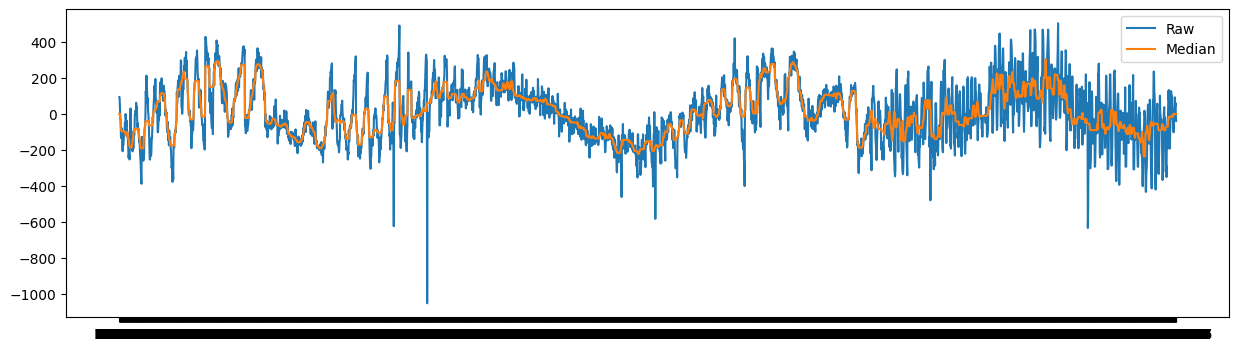

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(planet,label='Raw')
plt.plot(median_filtered,label='Median')
plt.legend()
plt.show()

Moving Average

In [ ]:
window = 21

moving_avg = pd.Series(planet).rolling(
    window=window,
    center=True
).mean()

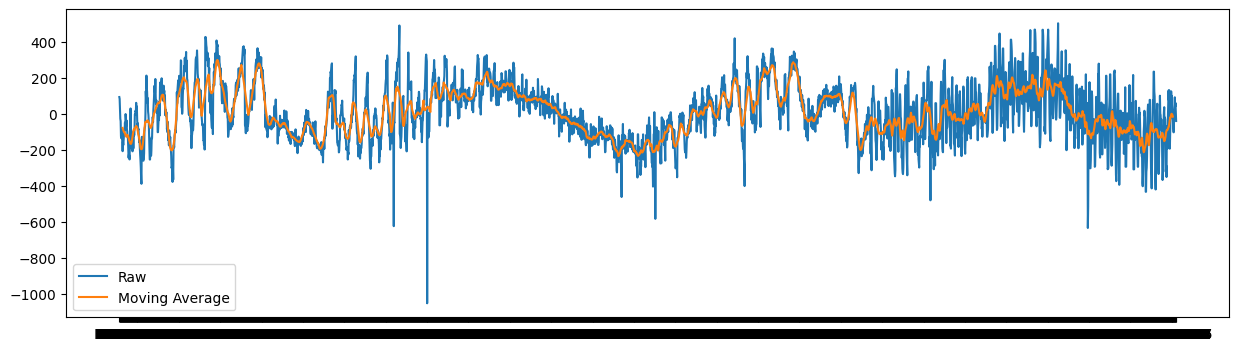

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(planet,label='Raw')
plt.plot(moving_avg,label='Moving Average')
plt.legend()
plt.show()

Building Baseline Model

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
pred = rf.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       565
           1       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(confusion_matrix(y_test, pred))

[[565   0]
 [  5   0]]


Installing imbalanceed learn

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

Apply SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [ ]:
print(y_train_smote.value_counts())

LABEL
1    5050
0    5050
Name: count, dtype: int64


Now since balanced retrain

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
pred = rf.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Classification Report")
print(classification_report(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       565
           1       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570


Confusion Matrix
[[565   0]
 [  5   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

LABEL
0    5050
1      37
Name: count, dtype: int64
LABEL
1    5050
0    5050
Name: count, dtype: int64


In [ ]:
pred = rf.predict(X_test_scaled)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       565
           1       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570

[[565   0]
 [  5   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Predicted planets:", pred.sum())

Predicted planets: 0


In [ ]:
prob = rf.predict_proba(X_test_scaled)[:,1]

print("Min:", prob.min())
print("Max:", prob.max())
print("Mean:", prob.mean())

print(sorted(prob, reverse=True)[:20])

Min: 0.0
Max: 0.225
Mean: 0.0448859649122807
[np.float64(0.225), np.float64(0.205), np.float64(0.19), np.float64(0.19), np.float64(0.19), np.float64(0.18), np.float64(0.18), np.float64(0.18), np.float64(0.175), np.float64(0.175), np.float64(0.175), np.float64(0.165), np.float64(0.165), np.float64(0.165), np.float64(0.165), np.float64(0.16), np.float64(0.16), np.float64(0.16), np.float64(0.155), np.float64(0.155)]


Sence lowering the threshold

In [ ]:
prob = rf.predict_proba(X_test_scaled)[:,1]

pred = (prob > 0.10).astype(int)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92       565
           1       0.05      0.80      0.09         5

    accuracy                           0.86       570
   macro avg       0.52      0.83      0.51       570
weighted avg       0.99      0.86      0.92       570

[[486  79]
 [  1   4]]


In [ ]:
for threshold in [0.05,0.10,0.15,0.20]:
    pred = (prob > threshold).astype(int)

    print("\nThreshold:", threshold)
    print(confusion_matrix(y_test,pred))


Threshold: 0.05
[[365 200]
 [  0   5]]

Threshold: 0.1
[[486  79]
 [  1   4]]

Threshold: 0.15
[[543  22]
 [  4   1]]

Threshold: 0.2
[[563   2]
 [  5   0]]


More test

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
prob = xgb.predict_proba(X_test_scaled)[:,1]

In [ ]:
for threshold in [0.05,0.10,0.15,0.20]:
    pred = (prob > threshold).astype(int)

    print("\nThreshold:", threshold)
    print(confusion_matrix(y_test,pred))


Threshold: 0.05
[[328 237]
 [  0   5]]

Threshold: 0.1
[[512  53]
 [  3   2]]

Threshold: 0.15
[[538  27]
 [  4   1]]

Threshold: 0.2
[[552  13]
 [  4   1]]


Cnn

In [ ]:
print(X_train_scaled.shape)

(5087, 3197)


Reshape

In [ ]:
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)